<a href="https://colab.research.google.com/github/it25101550/AI-ML-Project-16/blob/IT25101541/IT25101541.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing libraries
# System & File Handling
import os
import joblib
import warnings
from google.colab import files

# Data Handling & Analytics
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.exceptions import InconsistentVersionWarning

# ML Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
#Loading dataset
# 1. Upload CSV dataset
print("Upload 'fitness_dataset.csv' or 'fitness_dataset_2.csv':")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# 2. Load dataset into DataFrame
df = pd.read_csv(filename)

# 3. Overview of dataset characteristics
print("\n--- Dataset Summary ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print("\nColumn Data Types & Missing Values:")
print(df.info())

print("\nFirst 5 Rows:")
display(df.head())

print("\nTarget Variable Distribution ('is_fit'):")
print(df['is_fit'].value_counts())

Upload 'fitness_dataset.csv' or 'fitness_dataset_2.csv':


Saving fitness_dataset.csv to fitness_dataset.csv

--- Dataset Summary ---
Total Rows: 2000, Total Columns: 11

Column Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB
None

First 5 Rows:


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1



Target Variable Distribution ('is_fit'):
is_fit
0    1201
1     799
Name: count, dtype: int64


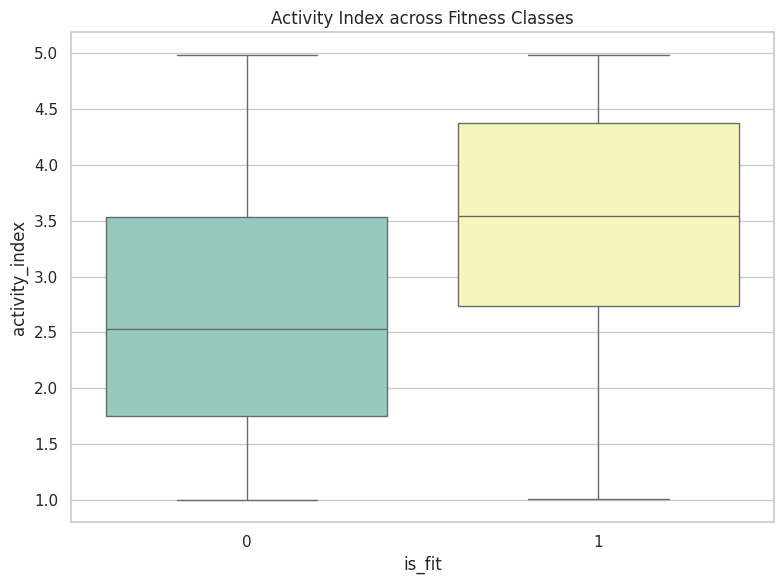

In [3]:
#EDA
#Box Plot - Activity Index spread across fitness classes
# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Plot 3: Activity Index Distribution
sns.boxplot(data=df, x='is_fit', y='activity_index', palette='Set3')
plt.title("Activity Index across Fitness Classes")

plt.tight_layout()
plt.show()

In [4]:
# Preprocessing
# handling missing data
# --- Setup carried over from Members 1-3 (needed to run this section) ---
df['smokes'] = df['smokes'].astype(str).str.lower().replace({'0': 'no', '1': 'yes'})

X = df.drop(columns=['is_fit'])
y = df['is_fit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure',
            'sleep_hours', 'nutrition_quality', 'activity_index']
cat_cols = ['smokes', 'gender']

# ---- MEMBER 4 OWN WORK STARTS HERE ----

# Missing values present before imputation
print("Missing values in training set BEFORE imputation:")
print(X_train[num_cols].isnull().sum())

# 4. Missing value median imputation
imputer = SimpleImputer(strategy='median')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

# Verification output for the viva
print("\nMissing values in training set AFTER imputation:")
print(X_train[num_cols].isnull().sum())

Missing values in training set BEFORE imputation:
age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          127
nutrition_quality      0
activity_index         0
dtype: int64

Missing values in training set AFTER imputation:
age                  0
height_cm            0
weight_kg            0
heart_rate           0
blood_pressure       0
sleep_hours          0
nutrition_quality    0
activity_index       0
dtype: int64


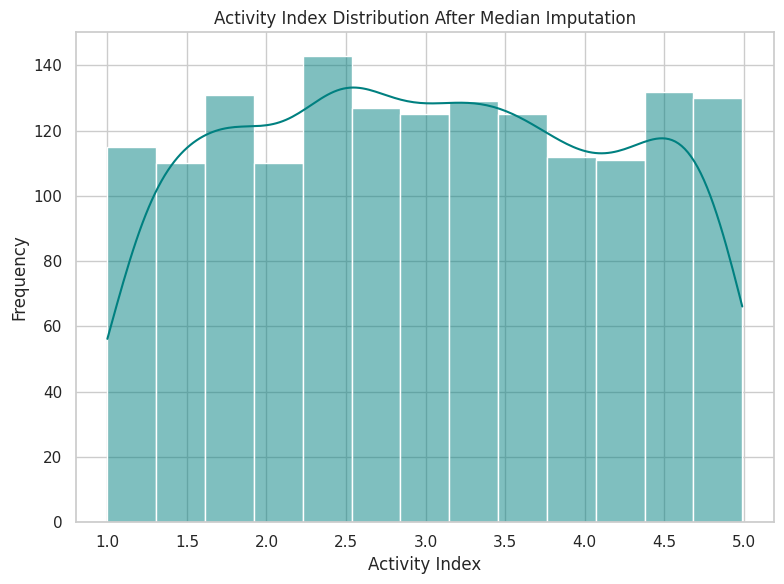

In [7]:
# EDA after preprocessing
plt.figure(figsize=(8, 6))
sns.histplot(X_train['activity_index'], kde=True, color='teal')
plt.title("Activity Index Distribution After Median Imputation")
plt.xlabel("Activity Index")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# downloading the file
train_out = 'member4_X_train_imputed.csv'
test_out = 'member4_X_test_imputed.csv'

X_train.to_csv(train_out, index=False)
X_test.to_csv(test_out, index=False)

print(f"Saved '{train_out}' and '{test_out}'")
files.download(train_out)
files.download(test_out)

Saved 'member4_X_train_imputed.csv' and 'member4_X_test_imputed.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>